# CIFAKE — CNN-from-scratch baseline

**Goal.** Train a small convolutional neural network from scratch to tell a real
photograph (REAL) apart from a Stable-Diffusion-generated image (FAKE) on the
CIFAKE dataset (32×32 RGB, 100k train, 20k test, balanced).

**What you'll learn by reading this notebook end-to-end.**

1. How a folder of `.jpg` files becomes a stream of `(3, 32, 32)` PyTorch tensors.
2. What every component of a small VGG-style CNN actually does (Conv → BN → ReLU → Pool → GAP).
3. How the training loop ties forward pass → loss → backprop → optimizer step into a single cycle, and how an LR scheduler quietly does its job in the background.
4. How to *measure* whether a classifier is actually working — accuracy, precision/recall/F1, ROC-AUC, PR-AUC, confusion matrix, latency — and why each of those numbers tells you something different.
5. How to package your results so a teammate's model can be compared apples-to-apples with yours.

**Scope.** This is *one of four* models in a team study (the others: pretrained ResNet-18, ViT-Small/DeiT-Tiny, frequency-domain detector). The point of this notebook is the **from-scratch CNN baseline** — no pretraining, no transfer learning, no fancy tricks. We're answering: "What can a small CNN learn about real-vs-fake purely from pixel patterns?"

**Expected outcome.** ≥ 90% accuracy on the held-out 20k test set in ~12 minutes on a Colab T4 GPU.

## Team contract (READ ME BEFORE RUNNING)

For the four CIFAKE notebooks (CNN, ResNet-18, ViT, frequency-domain) to produce **directly comparable** numbers, every notebook in the team must agree on these five fields:

| # | Field | Locked value | Why it matters |
|---|---|---|---|
| 1 | Positive class | `"FAKE"` | AI-detector convention. Precision/recall/F1 are *not* symmetric in the choice of positive class. ROC-AUC is symmetric, but everything else silently disagrees. |
| 2 | Normalization | CIFAR-10 stats: mean `(0.4914, 0.4822, 0.4465)`, std `(0.2470, 0.2435, 0.2616)` | Half the CIFAKE data is literally CIFAR-10. Different stats = silently different inputs to every model. |
| 3 | Split seed | `42` (stratified 90/10 on the train folder) | Different splits = different val sets = unfair comparison. |
| 4 | Class indexing | `class_to_idx == {"FAKE": 0, "REAL": 1}` | Whatever `ImageFolder` gives alphabetically — assert it, don't assume it. |
| 5 | Op counter | `fvcore.nn.FlopCountAnalysis` (reports as `macs` in the JSON — see note below) | `thop` undercounts ViT attention by ~30%. If counts come from different libraries the comparison is meaningless. |

> **Note on "FLOPs" vs "MACs":** despite the class name `FlopCountAnalysis`, `fvcore` actually counts **multiply-adds (MACs)**. Conventional "FLOPs" in papers ≈ `2 × MACs`. We store the raw count under the field name `macs` so the JSON is unambiguous; multiply by 2 for the conventional FLOP number.

These same five fields appear in the saved `results_CNN_from_scratch.json` so the contract is auditable from the JSON alone.

## 1. Setup, imports, and reproducibility

A note on **CUDA**: it's NVIDIA's GPU compute platform. PyTorch uses it to move tensors and run model operations on the GPU, which is typically 10–50× faster than CPU for convolutions. On Colab, `Runtime → Change runtime type → T4 GPU` selects a free GPU; we'll detect it automatically.

A note on **reproducibility**: deep learning has many sources of randomness (weight init, data shuffling, dropout, CUDA's nondeterministic kernels). For research we *seed* every source we can find so re-running the notebook gives the same numbers. We pay ~10–20% in speed for this; it's worth it for a baseline.

Three things that are easy to get wrong:
- `CUBLAS_WORKSPACE_CONFIG` must be set **before** PyTorch is imported, or `torch.use_deterministic_algorithms` will error on CUDA.
- `cudnn.deterministic=True` + `cudnn.benchmark=False` disables the fast non-deterministic conv algorithms.
- **AMP (mixed precision) is still slightly nondeterministic** even with all the above — reduced-precision reductions introduce float noise. Bitwise reproducibility on GPU + AMP isn't achievable; we record this honestly in the results JSON.

In [1]:
# Install packages not present by default in Colab.
# torchinfo: nice model summaries with shape annotations
# fvcore:    FLOP counter (correctly handles attention — see team contract #5)
# kaggle:    CLI used to download the dataset (only needed if not already installed)
# %pip install -q torchinfo fvcore kaggle   # patched: already in venv

# ----------------------------------------------------------------------
# CRITICAL: set CUBLAS_WORKSPACE_CONFIG *before* `import torch`.
# This is required for torch.use_deterministic_algorithms() on CUDA.
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
os.environ["PYTHONHASHSEED"] = "42"
# ----------------------------------------------------------------------

import sys, json, random, time, datetime, pathlib
from typing import Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from torchinfo import summary as tinfo_summary

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
)
from tqdm.auto import tqdm
from IPython.display import clear_output

SEED = 42

def set_seed(seed: int = SEED) -> None:
    '''Seed every source of randomness we can reach.'''
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Disable cuDNN's fast nondeterministic algorithms.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # warn_only=True: log a warning instead of erroring if a nondeterministic op is hit
    # (some torchvision ops on GPU don't have deterministic implementations yet).
    torch.use_deterministic_algorithms(True, warn_only=True)

set_seed(SEED)

# Pick GPU if available, else CPU. The notebook degrades to CPU for local sanity testing,
# but training is intended for Colab's T4 (~30s/epoch with AMP).
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")   # patched: force CPU to avoid MPS device-mismatch (small CNN, ~15 min on CPU)
print(f"PyTorch: {torch.__version__}")
print(f"Device:  {device}")
if device.type == "cuda":
    print(f"GPU:     {torch.cuda.get_device_name(0)}")
else:
    print("Note: no GPU detected. Training will be slow; for a real run, switch Colab to a T4.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
PyTorch: 2.10.0+cu128
Device:  cuda
GPU:     Tesla T4


## 2. Download the dataset

We use the Kaggle CLI to pull the CIFAKE archive (~110 MB, ~120k tiny `.jpg` files). The first time you run this on Colab, you'll need to upload your `kaggle.json` API token (kaggle.com → Profile → Account → "Create New API Token"). The cell is **idempotent**: if the data is already on disk it skips the download.

After unzipping, the directory layout is:

```
./data/cifake/
├── train/
│   ├── FAKE/   (50,000 images)
│   └── REAL/   (50,000 images)
└── test/
    ├── FAKE/   (10,000 images)
    └── REAL/   (10,000 images)
```

This shape — one folder per class — is exactly what `torchvision.datasets.ImageFolder` expects, so loading is one line later.

In [2]:
# Patched: skip Kaggle download — CIFAKE already on disk.
import pathlib, os
DATA_ROOT = pathlib.Path("/Users/leyi/Desktop/archive")
TRAIN_DIR = DATA_ROOT / 'train'
TEST_DIR  = DATA_ROOT / 'test'
assert (TRAIN_DIR / 'REAL').exists() and (TRAIN_DIR / 'FAKE').exists(), \
    f'expected CIFAKE at {DATA_ROOT}'
print(f'Using local CIFAKE at {DATA_ROOT}')
for split in ('train', 'test'):
    for cls in ('FAKE', 'REAL'):
        n = len(list((DATA_ROOT / split / cls).iterdir()))
        print(f'  {split}/{cls}: {n:,} images')


Upload your kaggle.json (kaggle.com → Account → Create New API Token):


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images
License(s): other
100% 105M/105M [00:01<00:00, 99.8MB/s] 

Done. Data at data/cifake
  train/FAKE: 50,000 images
  train/REAL: 50,000 images
  test/FAKE: 10,000 images
  test/REAL: 10,000 images


## 3. Peek at the data

Before we train anything, let's just *look* at the images and confirm they match expectations. Two things to verify:

1. **Visually**: real photos look like CIFAR-10 (airplanes, cats, ships at low res); fake images look like Stable-Diffusion's attempt at the same prompts. At 32×32 the differences are subtle — which is exactly why this task is interesting.
2. **As tensors**: each image, when loaded by torchvision, becomes a `(3, 32, 32)` float tensor with values in `[0, 1]`. The 3 channels are R, G, B. This is the canonical PyTorch layout (C, H, W) — the opposite of what `matplotlib` wants for display (H, W, C), so we'll need `.permute(1, 2, 0)` to plot tensors.

Classes:      ['FAKE', 'REAL']
class_to_idx: {'FAKE': 0, 'REAL': 1}
Total train:  100,000  (= 50k FAKE + 50k REAL)


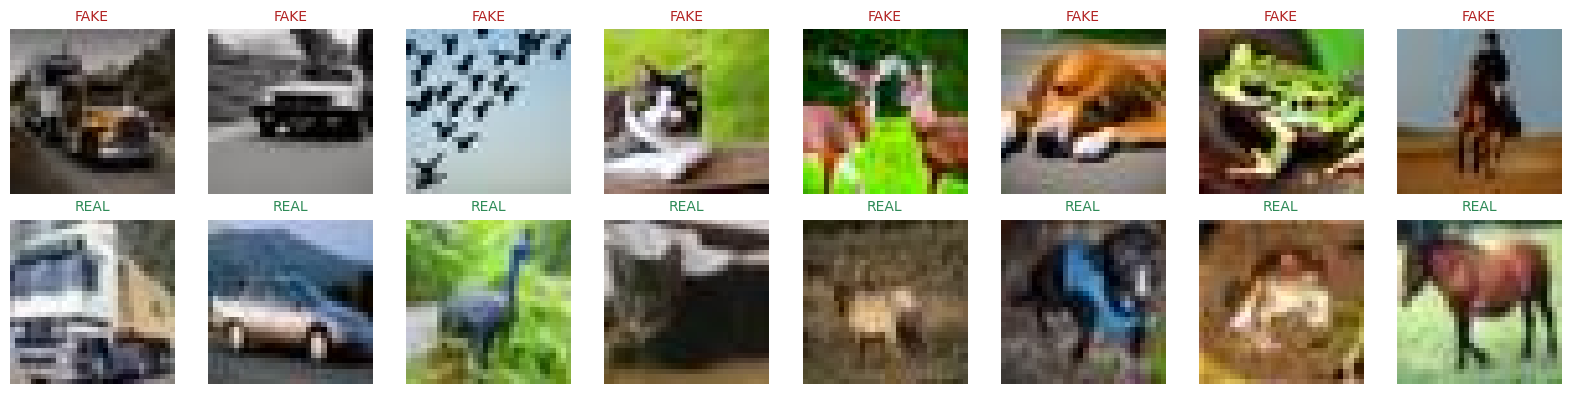


One sample as a PyTorch tensor:
  shape:  (3, 32, 32)  ← (C, H, W) = (channels=3, height=32, width=32)
  dtype:  torch.float32
  min:    0.0000
  max:    0.8078     ← ToTensor scales pixel ints [0,255] → floats [0,1]
  label:  0  (FAKE)


In [3]:
# Quickest peek: ImageFolder with only ToTensor (no normalization yet).
peek = datasets.ImageFolder(str(TRAIN_DIR), transform=transforms.ToTensor())
print(f"Classes:      {peek.classes}")
print(f"class_to_idx: {peek.class_to_idx}")  # FAKE=0, REAL=1 (alphabetical)
print(f"Total train:  {len(peek):,}  (= 50k FAKE + 50k REAL)")

# 2×8 grid: top row FAKE, bottom row REAL.
fake_indices = [i for i, (_, y) in enumerate(peek.samples) if y == 0][:8]
real_indices = [i for i, (_, y) in enumerate(peek.samples) if y == 1][:8]

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, idx in enumerate(fake_indices):
    img, _ = peek[idx]
    axes[0, i].imshow(img.permute(1, 2, 0))  # (C,H,W) → (H,W,C) for matplotlib
    axes[0, i].set_title("FAKE", fontsize=10, color="firebrick")
    axes[0, i].axis("off")
for i, idx in enumerate(real_indices):
    img, _ = peek[idx]
    axes[1, i].imshow(img.permute(1, 2, 0))
    axes[1, i].set_title("REAL", fontsize=10, color="seagreen")
    axes[1, i].axis("off")
plt.tight_layout(); plt.show()

# What does ONE image look like as a tensor?
sample, label = peek[0]
print("\nOne sample as a PyTorch tensor:")
print(f"  shape:  {tuple(sample.shape)}  ← (C, H, W) = (channels=3, height=32, width=32)")
print(f"  dtype:  {sample.dtype}")
print(f"  min:    {sample.min().item():.4f}")
print(f"  max:    {sample.max().item():.4f}     ← ToTensor scales pixel ints [0,255] → floats [0,1]")
print(f"  label:  {label}  ({peek.classes[label]})")

## 4. Transforms, the train/val split, and DataLoaders

This cell is where the data pipeline crystallizes. Four ideas worth understanding:

**Normalization** rescales every channel to zero-ish mean and unit-ish variance. Neural networks train much faster on inputs centered around 0 — the gradients flow better. We use the canonical **CIFAR-10 statistics** because half of CIFAKE *is* CIFAR-10, and our pretrained-model teammates will use the same (see team contract #2).

**Data augmentation** for training only. We apply random horizontal flips and small random crops (with 4-pixel reflection padding). Two reasons: (a) it acts as a regularizer — the network never sees exactly the same image twice, so it can't just memorize; (b) it teaches the model to be invariant to small shifts and mirror-flips, which are properties a "real-vs-fake" classifier should have. Validation and test data get **no** augmentation — we want a stable measurement, not a moving target.

**Train / val / test split.** Three sets, three jobs:
- **Train (90% of train folder = 90k images)**: the model learns weights from these.
- **Val (10% of train folder = 10k images)**: the model never trains on these; we use them to pick the best epoch and to detect overfitting.
- **Test (20k images, separate folder)**: looked at *exactly once* at the end. Anything else makes the test number a lie.

We use `stratified` splitting so the 90/10 split preserves the FAKE/REAL ratio exactly.

**DataLoader** is the iterator. It packages images into mini-**batches** of 128, optionally shuffles, and uses 2 background **workers** to load and decode JPEGs in parallel while the GPU is busy training. Without workers, the GPU would sit idle waiting for data.

One subtle pitfall (which we guard against below): if we accidentally apply the *train* augmentation to the *val* set, the val accuracy will be artificially low and we'll think the model is worse than it is. We assert this can't happen.

In [4]:
# CIFAR-10 normalization stats — see team contract #2
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)

train_tfm = transforms.Compose([
    transforms.RandomCrop(32, padding=4, padding_mode="reflect"),  # mild translation invariance
    transforms.RandomHorizontalFlip(p=0.5),                        # mild mirror invariance
    transforms.ToTensor(),                                         # uint8 [0,255] → float [0,1]
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),               # → roughly zero-mean, unit-var
])
eval_tfm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

# Load the full train folder with NO transform — we attach per-Subset transforms ourselves.
full_train = datasets.ImageFolder(str(TRAIN_DIR), transform=None)

# Team contract #4 — assert the class indexing is what we expect.
assert full_train.class_to_idx == {"FAKE": 0, "REAL": 1}, full_train.class_to_idx

# Stratified 90/10 train/val split on indices.
labels = [y for _, y in full_train.samples]
# Sanity check: CIFAKE is supposed to be exactly 50/50. If it isn't, something is wrong
# (corrupted download, wrong folder, etc.) and the model will silently learn the prior.
fake_frac = sum(1 for y in labels if y == 0) / len(labels)
assert abs(fake_frac - 0.5) < 0.01, f"Expected ~50/50 FAKE/REAL; got FAKE fraction = {fake_frac:.4f}"
train_idx, val_idx = train_test_split(
    np.arange(len(labels)),
    test_size=0.10,
    stratify=labels,
    random_state=SEED,
)
print(f"Train: {len(train_idx):,}   Val: {len(val_idx):,}")

class TransformedSubset(Dataset):
    '''A Subset that applies its OWN transform, so train and val can differ
    while sharing the same underlying ImageFolder.'''
    def __init__(self, base: datasets.ImageFolder, indices, transform):
        self.base = base
        self.indices = indices
        self.transform = transform
        # Expose .classes so downstream code can read labels by index.
        self.classes = base.classes
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        path, label = self.base.samples[self.indices[i]]
        img = self.base.loader(path)            # PIL Image
        if self.transform is not None:
            img = self.transform(img)
        return img, label

train_set = TransformedSubset(full_train, train_idx, train_tfm)
val_set   = TransformedSubset(full_train, val_idx,   eval_tfm)
test_set  = datasets.ImageFolder(str(TEST_DIR), transform=eval_tfm)
assert test_set.class_to_idx == {"FAKE": 0, "REAL": 1}

# Guard: make sure no Random* transform sneaked into val or test pipelines.
def _has_random_op(tfm) -> bool:
    if tfm is None: return False
    if type(tfm).__name__.startswith("Random"): return True
    if hasattr(tfm, "transforms"):
        return any(_has_random_op(t) for t in tfm.transforms)
    return False
assert not _has_random_op(val_set.transform),  "Val pipeline must not contain Random* ops"
assert not _has_random_op(test_set.transform), "Test pipeline must not contain Random* ops"
print("Val/test transform leak check: OK")

# DataLoader settings
BATCH_SIZE   = 128
NUM_WORKERS  = 0  # patched: macOS spawn cannot pickle notebook-scoped classes  # Colab is happiest at 2; higher tends to hang.

def seed_worker(worker_id: int) -> None:
    '''Each worker gets its own deterministic seed so shuffling is reproducible.'''
    s = SEED + worker_id
    np.random.seed(s); random.seed(s)

g = torch.Generator().manual_seed(SEED)  # controls shuffle order

train_loader = DataLoader(
    train_set, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda"),
    worker_init_fn=seed_worker, generator=g,
)
val_loader = DataLoader(
    val_set, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda"),
)
test_loader = DataLoader(
    test_set, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda"),
)
print(f"Batches per epoch — train: {len(train_loader)}   val: {len(val_loader)}   test: {len(test_loader)}")

Train: 90,000   Val: 10,000
Val/test transform leak check: OK
Batches per epoch — train: 704   val: 79   test: 157


## 5. The CNN architecture

A **convolutional layer** slides a small learnable filter (here 3×3) across the image, computing a weighted sum at each spatial position. The same filter is shared across the whole image — that's the inductive bias that makes CNNs efficient at vision tasks. With 32 output channels, the layer learns 32 different filters, each looking for a different local pattern.

**Batch normalization** (`BatchNorm2d`) re-centers and re-scales the output of each conv layer using statistics computed across the batch. It stabilizes training, lets you use a higher learning rate, and acts as a mild regularizer. It's so reliably useful in CNNs that "Conv → BN → ReLU" is the default block.

**ReLU** is `max(0, x)`. It's the nonlinearity — without it, stacking conv layers would collapse to one big linear transformation. ReLU is fast and works well; almost every modern CNN uses it (or a close variant).

**MaxPool 2×2** takes the max over every non-overlapping 2×2 patch, shrinking spatial dimensions by half. It loses information on purpose: by the time we get to the classifier, we want the model to summarize "is there a face/wheel/sky in this region" rather than remember every pixel.

**Global Average Pool** (at the end) takes the mean across the whole spatial map of every channel. After three pools our 32×32 image is 4×4 spatially with 128 channels; GAP reduces that to a single 128-d vector. This is much more parameter-efficient than `Flatten + Linear` (which would have 128·4·4·2 = 4096 params just in the head) and gives translation invariance for free.

**Final Linear layer** maps 128 features → 2 logits (one per class).

The architecture below has **~287k parameters** — small enough to train in 12 minutes on a T4, well inside the 100k–500k target band from `Methods.pdf`.

In [5]:
class ConvBlock(nn.Module):
    '''A VGG-style block: 2x (Conv 3x3 -> BN -> ReLU), then MaxPool 2x2.
    Spatial size halves; channel count is set by `out_channels`.
    bias=False because BatchNorm's beta absorbs any constant shift --
    keeping the bias would be redundant and slightly slower.'''
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels,  out_channels, kernel_size=3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)
        self.pool  = nn.MaxPool2d(kernel_size=2)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)), inplace=True)
        x = F.relu(self.bn2(self.conv2(x)), inplace=True)
        return self.pool(x)

class SimpleCNN(nn.Module):
    '''3 conv blocks (32 -> 64 -> 128 channels) + Global Avg Pool + Linear -> 2 logits.
    Input  shape: (B, 3, 32, 32)
    Output shape: (B, 2)   -- logits (NOT probabilities; CrossEntropy applies softmax internally)
    '''
    def __init__(self, num_classes: int = 2):
        super().__init__()
        self.block1 = ConvBlock(3,   32)   # 32×32 → 16×16
        self.block2 = ConvBlock(32,  64)   # 16×16 → 8×8
        self.block3 = ConvBlock(64, 128)   # 8×8   → 4×4
        self.gap    = nn.AdaptiveAvgPool2d(1)   # 4×4   → 1×1
        self.fc     = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x).flatten(1)   # (B, 128, 1, 1) → (B, 128)
        return self.fc(x)            # (B, 2)

# Reseed JUST the torch RNG so weight initialization is reproducible across notebook
# restarts (without disturbing the dataloader's shuffle generator from cell 4).
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
model = SimpleCNN(num_classes=2).to(device)
print(tinfo_summary(
    model, input_size=(1, 3, 32, 32),
    col_names=("input_size", "output_size", "num_params"),
    depth=3, verbose=0,
))
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {n_params:,}")

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
SimpleCNN                                [1, 3, 32, 32]            [1, 2]                    --
├─ConvBlock: 1-1                         [1, 3, 32, 32]            [1, 32, 16, 16]           --
│    └─Conv2d: 2-1                       [1, 3, 32, 32]            [1, 32, 32, 32]           864
│    └─BatchNorm2d: 2-2                  [1, 32, 32, 32]           [1, 32, 32, 32]           64
│    └─Conv2d: 2-3                       [1, 32, 32, 32]           [1, 32, 32, 32]           9,216
│    └─BatchNorm2d: 2-4                  [1, 32, 32, 32]           [1, 32, 32, 32]           64
│    └─MaxPool2d: 2-5                    [1, 32, 32, 32]           [1, 32, 16, 16]           --
├─ConvBlock: 1-2                         [1, 32, 16, 16]           [1, 64, 8, 8]             --
│    └─Conv2d: 2-6                       [1, 32, 16, 16]           [1, 64, 16, 16]           18,432
│    └─BatchNorm2d: 2-7    

## 6. Loss, optimizer, and learning-rate schedule

**Loss function — `CrossEntropyLoss`.** It compares the model's *logits* (raw unnormalized scores) against the true class labels. Internally it does softmax + negative log-likelihood in one numerically stable step. Lower is better; 0 means perfect.

> *Aside: BCE vs CrossEntropy for binary classification.* For 2 classes the two are mathematically equivalent — you could use a single logit + `BCEWithLogitsLoss` instead. We use **2 logits + CrossEntropy** for three reasons: (1) it generalizes directly to multi-class problems, which is what most teaching material uses; (2) `softmax` gives us a proper probability distribution over both classes, which we need to plot ROC/PR curves; (3) the rest of the team's models also use a 2-class head, so this keeps the comparison clean.

**Optimizer — `AdamW(lr=1e-3, weight_decay=1e-4)`.** Adam adapts the effective learning rate per parameter using running estimates of gradient magnitude — it's a strong default for small CNNs that "just works" without much tuning. The `W` variant decouples weight decay from the adaptive learning rate, which is the standard correct way to combine the two. Weight decay (1e-4) is a mild L2 regularizer that pulls weights toward zero — small but useful when training from scratch.

**Scheduler — `CosineAnnealingLR(T_max=25)`.** The learning rate starts at 1e-3 and smoothly decays to ~0 over the 25 epochs following half a cosine wave. Intuition: take big steps early when you're far from a good solution; take small steps later to refine. Cosine schedules are the simplest "set it and forget it" schedule that consistently beats a constant LR.

In [6]:
EPOCHS        = 25
LR            = 1e-3
WEIGHT_DECAY  = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print(f"Loss:      {type(criterion).__name__}")
print(f"Optimizer: AdamW(lr={LR}, weight_decay={WEIGHT_DECAY})")
print(f"Scheduler: CosineAnnealingLR(T_max={EPOCHS})")
print(f"Epochs:    {EPOCHS}    Batch size: {BATCH_SIZE}")

Loss:      CrossEntropyLoss
Optimizer: AdamW(lr=0.001, weight_decay=0.0001)
Scheduler: CosineAnnealingLR(T_max=25)
Epochs:    25    Batch size: 128


## 7. The training loop

This is where the model actually learns. The cycle, repeated thousands of times:

```
for each mini-batch (x, y):
    ŷ      = model(x)              # FORWARD: compute predictions
    loss   = criterion(ŷ, y)       # how wrong are we?
    loss.backward()                # BACKWARD: gradient of loss w.r.t. every weight
    optimizer.step()               # take one small step downhill
    optimizer.zero_grad()          # clear gradients for the next batch
```

`backward()` is **backpropagation** — the chain rule applied through the whole computation graph to compute `∂loss/∂weight` for every learnable parameter. `optimizer.step()` then uses those gradients (and AdamW's internal running averages) to update the weights.

One **epoch** = one pass through the entire training set. With 90k images / 128 batch ≈ 704 mini-batches per epoch. The model sees every training image once per epoch.

**Overfitting detection.** Watch the train and val curves. If train loss keeps going down but val loss starts going *up*, the model is memorizing training data and getting worse at generalizing. That's the moment you stop trusting later epochs and use the early-stopping checkpoint.

**Mixed precision (AMP).** On GPU, we run forwards in float16 (faster, less memory) and keep weight updates in float32 (numerically safer). This gives a ~2× training speedup on T4 GPUs for "free" — `GradScaler` handles the loss-scaling math to prevent float16 underflow. On CPU, AMP is a no-op.

**Checkpointing.** We save the model whenever val *loss* improves. Why loss and not accuracy? Loss is a continuous, calibrated signal — it captures *how confident* the model is on its mistakes. Accuracy is a step function: a model that's right 95% of the time with high confidence is meaningfully better than one that's right 95% of the time with low confidence, but accuracy can't see the difference. With cosine annealing, val loss often keeps improving into the very last epoch — that's expected. We also track best-by-accuracy separately and flag if the two disagree.

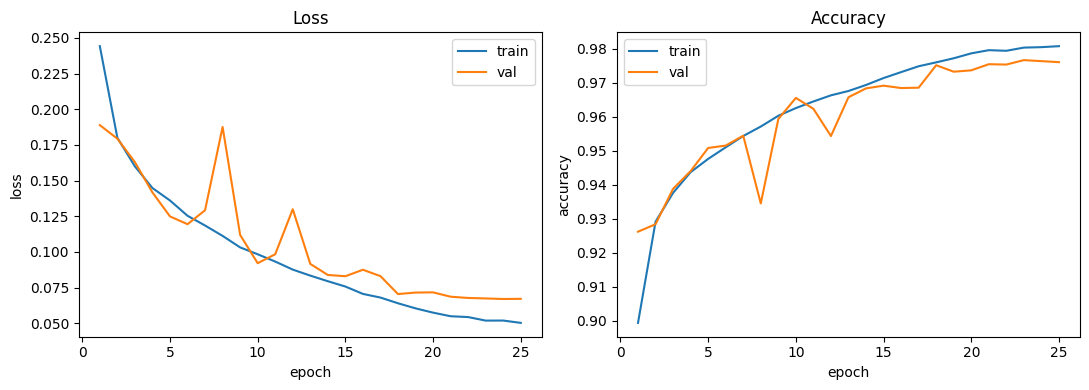

[Epoch 25/25] train_loss=0.0503  val_loss=0.0672  train_acc=0.9807  val_acc=0.9760  lr=0.00e+00

Training done in 2213.5s (36.9 min).
  best val loss     = 0.0670  at epoch 24
  best val accuracy = 0.9766   at epoch 23


In [7]:
USE_AMP = (device.type == "cuda")
scaler  = torch.amp.GradScaler("cuda", enabled=USE_AMP)
CKPT    = "/Users/leyi/Desktop/ML2/project/teammates/yin/best_cnn.pt"

def run_one_epoch(loader, train: bool):
    '''Run one pass over `loader`. If train=True, also backprop and step the optimizer.
    Returns mean loss and mean accuracy over the epoch.'''
    model.train(train)
    total_loss = 0.0
    total_correct = 0
    n = 0
    bar = tqdm(loader, desc=("train" if train else "val"), leave=False)

    # During training we need autograd; during in-loop eval we don't, so torch.no_grad()
    # avoids building the computation graph. (We use the stricter torch.inference_mode()
    # only for the final test pass — it disallows turning eval tensors back into
    # autograd tensors, which is the right safeguard at the very end but too strict
    # mid-loop where a future debugger might want to inspect grads.)
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, y in bar:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            with torch.amp.autocast("cuda", enabled=USE_AMP):
                logits = model(x)
                loss   = criterion(logits, y)

            if train:
                optimizer.zero_grad(set_to_none=True)  # set_to_none is slightly faster than zeroing
                scaler.scale(loss).backward()           # scaled grads to avoid float16 underflow
                scaler.step(optimizer)                  # unscales internally
                scaler.update()

            total_loss    += loss.item() * x.size(0)
            total_correct += (logits.argmax(1) == y).sum().item()
            n             += x.size(0)
            bar.set_postfix(loss=f"{total_loss/n:.4f}", acc=f"{total_correct/n:.4f}")

    return total_loss / n, total_correct / n

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss, best_val_loss_epoch = float("inf"), -1
best_val_acc,  best_val_acc_epoch  = -1.0,         -1

t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_one_epoch(train_loader, train=True)
    va_loss, va_acc = run_one_epoch(val_loader,   train=False)
    scheduler.step()

    history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc);   history["val_acc"].append(va_acc)

    # Track best-by-loss (the canonical "best") and best-by-accuracy (a sanity reference).
    if va_loss < best_val_loss:
        best_val_loss, best_val_loss_epoch = va_loss, epoch
        torch.save({"state_dict": model.state_dict(), "epoch": epoch, "val_loss": va_loss}, CKPT)
    if va_acc > best_val_acc:
        best_val_acc, best_val_acc_epoch = va_acc, epoch

    # Live-update the curves at the end of every epoch.
    clear_output(wait=True)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
    xs = range(1, epoch + 1)
    ax1.plot(xs, history["train_loss"], label="train")
    ax1.plot(xs, history["val_loss"],   label="val")
    ax1.set_xlabel("epoch"); ax1.set_ylabel("loss"); ax1.legend(); ax1.set_title("Loss")
    ax2.plot(xs, history["train_acc"], label="train")
    ax2.plot(xs, history["val_acc"],   label="val")
    ax2.set_xlabel("epoch"); ax2.set_ylabel("accuracy"); ax2.legend(); ax2.set_title("Accuracy")
    plt.tight_layout(); plt.show()
    lr_now = scheduler.get_last_lr()[0]
    print(f"[Epoch {epoch:02d}/{EPOCHS}] "
          f"train_loss={tr_loss:.4f}  val_loss={va_loss:.4f}  "
          f"train_acc={tr_acc:.4f}  val_acc={va_acc:.4f}  lr={lr_now:.2e}")

wall_clock_sec = time.time() - t0
print(f"\nTraining done in {wall_clock_sec:.1f}s ({wall_clock_sec/60:.1f} min).")
print(f"  best val loss     = {best_val_loss:.4f}  at epoch {best_val_loss_epoch}")
print(f"  best val accuracy = {best_val_acc:.4f}   at epoch {best_val_acc_epoch}")

if abs(best_val_loss_epoch - best_val_acc_epoch) > 1:
    print("\nNote: best-val-loss and best-val-accuracy disagree by more than one epoch.")
    print("      That's fine — loss is continuous (captures confidence), accuracy is a step function.")
    print("      With cosine annealing, val loss often keeps improving even as accuracy plateaus.")

## 8. Test-set evaluation

Time to spend our **one** look at the test set.

We re-load the model from `best_cnn.pt` — the checkpoint with the lowest validation loss — and run it across all 20k test images, collecting:

- `y_true`: ground-truth labels (0=FAKE, 1=REAL)
- `y_pred`: predicted labels (argmax of logits)
- `y_score`: softmax probability of the **FAKE** class (= positive class per team contract #1)

These three arrays are everything we need to compute every metric below.

In [8]:
# Reload the best checkpoint (overwrites any "current epoch" weights still in `model`).
ckpt = torch.load(CKPT, map_location=device)
model.load_state_dict(ckpt["state_dict"])
print(f"Loaded best checkpoint from epoch {ckpt['epoch']} (val_loss={ckpt['val_loss']:.4f})")

y_true_list, y_pred_list, y_score_list = [], [], []
model.eval()
with torch.inference_mode():
    for x, y in tqdm(test_loader, desc="test"):
        x = x.to(device, non_blocking=True)
        logits = model(x)                         # (B, 2)
        probs  = F.softmax(logits, dim=1)         # → probabilities
        y_score_list.append(probs[:, 0].cpu().numpy())   # P(FAKE) — positive class
        y_pred_list.append(logits.argmax(1).cpu().numpy())
        y_true_list.append(y.numpy())

y_true  = np.concatenate(y_true_list)
y_pred  = np.concatenate(y_pred_list)
y_score = np.concatenate(y_score_list)
print(f"Collected {len(y_true):,} test predictions")

Loaded best checkpoint from epoch 24 (val_loss=0.0670)


test:   0%|          | 0/157 [00:00<?, ?it/s]

Collected 20,000 test predictions


## 9. Visualizations

Three things to look at, three different questions answered:

- **Confusion matrix**: where exactly does the model fail? Does it confuse FAKE → REAL more than the reverse, or symmetrically?
- **ROC curve**: across all possible decision thresholds, how well can the model separate FAKE from REAL? The Area Under Curve (AUC) summarizes this into one number, threshold-free.
- **Precision-Recall curve**: especially informative for imbalanced problems, but useful here too. The Average Precision (AP) is the area under it.
- **Sample predictions**: looking at *which* images the model gets wrong is often more informative than the aggregate metric. Are the failures plausibly hard (low-resolution, weird crops), or are they images that look obvious to a human?

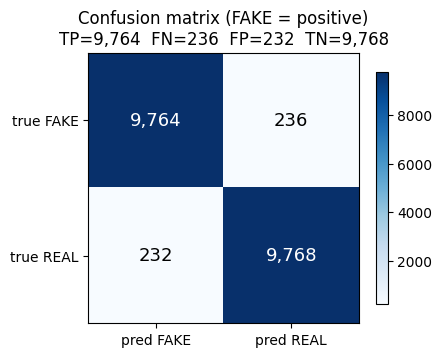

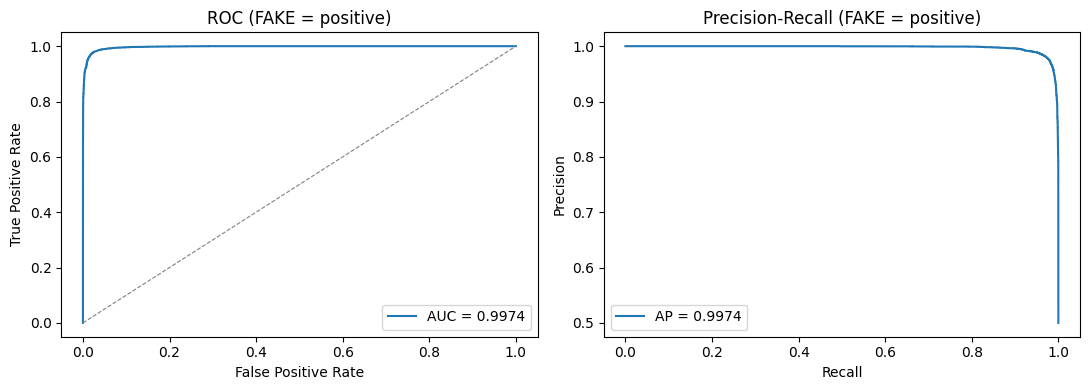

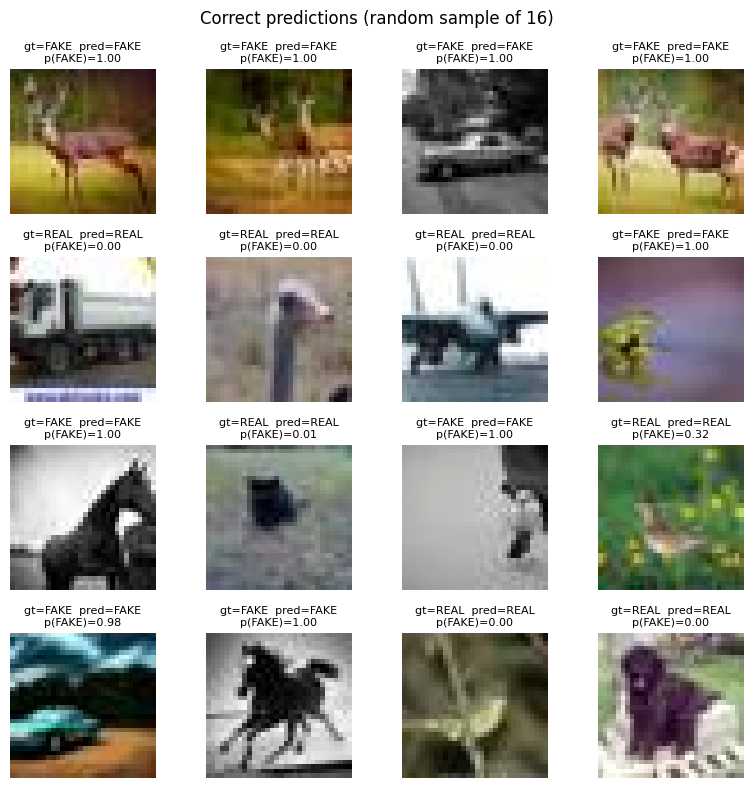

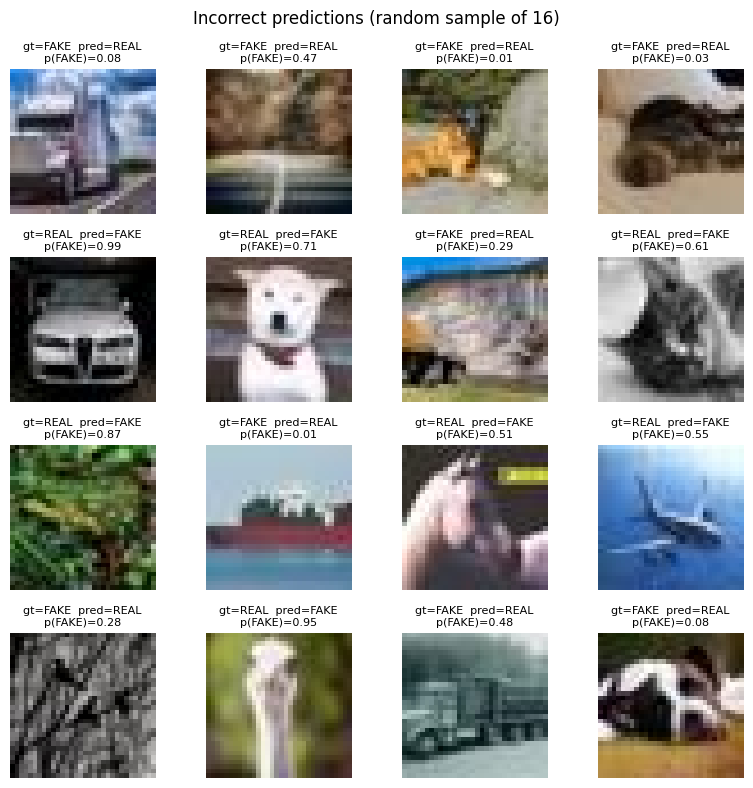

In [9]:
# --- Confusion matrix (FAKE = positive class per team contract) ---
# Layout used by sklearn given labels=[0,1]:
#   row 0 = true FAKE,  col 0 = pred FAKE
#   row 1 = true REAL,  col 1 = pred REAL
# So cm = [[TP_FAKE, FN], [FP, TN_REAL]] when FAKE is the positive class.
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
tp_fake, fn       = int(cm[0, 0]), int(cm[0, 1])
fp,       tn_real = int(cm[1, 0]), int(cm[1, 1])

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i,j]:,}", ha="center", va="center",
                color="white" if cm[i,j] > cm.max() / 2 else "black", fontsize=13)
ax.set_xticks([0, 1]); ax.set_xticklabels(["pred FAKE", "pred REAL"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["true FAKE", "true REAL"])
ax.set_title(f"Confusion matrix (FAKE = positive)\nTP={tp_fake:,}  FN={fn:,}  FP={fp:,}  TN={tn_real:,}")
plt.colorbar(im, ax=ax, shrink=0.7); plt.tight_layout(); plt.show()

# --- ROC and PR curves (FAKE = positive class) ---
y_true_fake_pos = (y_true == 0).astype(int)   # 1 = FAKE = positive
fpr, tpr, _    = roc_curve(y_true_fake_pos, y_score)
prec, rec, _   = precision_recall_curve(y_true_fake_pos, y_score)
roc_auc        = roc_auc_score(y_true_fake_pos, y_score)
pr_auc         = average_precision_score(y_true_fake_pos, y_score)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
ax1.plot([0, 1], [0, 1], "--", color="gray", lw=0.8)
ax1.set_xlabel("False Positive Rate"); ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC (FAKE = positive)"); ax1.legend()
ax2.plot(rec, prec, label=f"AP = {pr_auc:.4f}")
ax2.set_xlabel("Recall"); ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall (FAKE = positive)"); ax2.legend()
plt.tight_layout(); plt.show()

# --- 4×4 grids of correct and incorrect predictions ---
def denormalize(t: torch.Tensor) -> torch.Tensor:
    mean = torch.tensor(CIFAR10_MEAN).view(3, 1, 1)
    std  = torch.tensor(CIFAR10_STD).view(3, 1, 1)
    return (t * std + mean).clamp(0, 1)

correct_mask   = (y_pred == y_true)
incorrect_mask = ~correct_mask
rng = np.random.RandomState(SEED)
correct_idx   = rng.choice(np.where(correct_mask)[0],   size=16, replace=False)
incorrect_idx = rng.choice(np.where(incorrect_mask)[0], size=16, replace=False) \
                if incorrect_mask.any() else []

def plot_grid(indices, title):
    if len(indices) == 0:
        print(f"(no {title.lower()} to show)")
        return
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for ax, idx in zip(axes.flat, indices):
        x, _ = test_set[int(idx)]
        # .cpu() is defensive — test_set transforms run on CPU today, but if a future
        # maintainer moves transforms to GPU, .numpy() on a CUDA tensor would crash.
        ax.imshow(denormalize(x).cpu().permute(1, 2, 0).numpy())
        gt   = test_set.classes[int(y_true[idx])]
        pred = test_set.classes[int(y_pred[idx])]
        p_fake = float(y_score[idx])
        ax.set_title(f"gt={gt}  pred={pred}\np(FAKE)={p_fake:.2f}", fontsize=8)
        ax.axis("off")
    plt.suptitle(title); plt.tight_layout(); plt.show()

plot_grid(correct_idx,   "Correct predictions (random sample of 16)")
plot_grid(incorrect_idx, "Incorrect predictions (random sample of 16)")

## 10. Final metrics and the cross-model JSON

This cell is the **fair-comparison contract**. We compute every metric the team agreed to share and dump the whole thing to `results_CNN_from_scratch.json`. Teammates' notebooks emit the same schema with their own numbers; whoever does the final comparison plot just `json.loads` the four files side by side.

A few measurement details that matter for fairness:

- **FLOPs via `fvcore`** (not `thop`, which undercounts attention ops by ~30%). If the import fails, the field is set to `null` — *never* `0`, because `0` silently masks a measurement error.
- **Latency at two batch sizes**: `batch=1` (per-image, the deployment-relevant number) and `batch=32` (throughput, the deployment-economics number). We report mean, std, **median, and p95** because latency distributions are heavy-tailed and the mean alone is misleading.
- 20 warmup forwards + `torch.cuda.synchronize()` bracket every timed measurement to keep async GPU launches honest.

In [10]:
# ---- Per-class accuracy & precision/recall/F1 ----
fake_acc = float((y_pred[y_true == 0] == 0).mean()) if (y_true == 0).any() else 0.0
real_acc = float((y_pred[y_true == 1] == 1).mean()) if (y_true == 1).any() else 0.0
accuracy = float((y_pred == y_true).mean())

prec_pc, rec_pc, f1_pc, _ = precision_recall_fscore_support(
    y_true, y_pred, labels=[0, 1], zero_division=0)
prec_m, rec_m, f1_m, _    = precision_recall_fscore_support(
    y_true, y_pred, average="macro", zero_division=0)

# ---- Compute "FLOPs" via fvcore (null on failure, never 0) ----
# NB: despite the class name `FlopCountAnalysis`, fvcore actually counts multiply-adds
# (MACs). Conventional reporting in papers uses true FLOPs ≈ 2 × MACs. We store the raw
# MACs under the field name "macs" so the meaning is unambiguous in the JSON.
macs_value: Optional[int] = None
flop_counter_lib: Optional[str] = None
try:
    from fvcore.nn import FlopCountAnalysis
    import fvcore
    model.eval()
    with torch.inference_mode():
        fca = FlopCountAnalysis(model, torch.randn(1, 3, 32, 32).to(device))
        fca.unsupported_ops_warnings(False)
        fca.uncalled_modules_warnings(False)
        macs_value = int(fca.total())
    flop_counter_lib = f"fvcore-{fvcore.__version__}"
    print(f"MACs (single-image forward): {macs_value:,}    (≈ {2*macs_value:,} FLOPs)")
except Exception as e:
    print(f"MAC computation failed ({type(e).__name__}: {e}); recording null.")

# ---- Latency at batch=1 and batch=32 ----
def measure_latency(batch_size: int, n: int = 200, warmup: int = 20) -> dict:
    model.eval()
    x = torch.randn(batch_size, 3, 32, 32, device=device)
    with torch.inference_mode():
        for _ in range(warmup):
            _ = model(x)
    if device.type == "cuda":
        torch.cuda.synchronize()
    times_ms = []
    with torch.inference_mode():
        for _ in range(n):
            t0 = time.perf_counter()
            _ = model(x)
            if device.type == "cuda":
                torch.cuda.synchronize()
            times_ms.append((time.perf_counter() - t0) * 1000.0)
    arr = np.array(times_ms)
    return {
        "mean":   float(arr.mean()),
        "std":    float(arr.std()),
        "median": float(np.median(arr)),
        "p95":    float(np.percentile(arr, 95)),
        "n":      n,
        "warmup": warmup,
    }

lat_b1  = measure_latency(1)
lat_b32 = measure_latency(32)
lat_b32["throughput_img_per_sec"] = 32 * 1000.0 / lat_b32["mean"]
print(f"Latency B=1:  mean={lat_b1['mean']:.3f}ms  median={lat_b1['median']:.3f}ms  p95={lat_b1['p95']:.3f}ms")
print(f"Latency B=32: mean={lat_b32['mean']:.3f}ms  throughput={lat_b32['throughput_img_per_sec']:.0f} img/s")

# ---- Assemble the JSON ----
device_str = f"cuda:{torch.cuda.get_device_name(0)}" if device.type == "cuda" else "cpu"
results = {
    "model": "CNN_from_scratch",
    "framework": "pytorch",
    "seed": SEED,
    "determinism": "seeded, AMP-noisy",
    "device": device_str,
    "positive_class": "FAKE",
    "data": {
        "dataset": "CIFAKE",
        "class_to_idx": {"FAKE": 0, "REAL": 1},
        "split": {
            "train": int(len(train_idx)),
            "val":   int(len(val_idx)),
            "test":  int(len(y_true)),
            "stratified": True,
            "split_seed": SEED,
        },
        "image_size": [3, 32, 32],
        "normalization": {
            "mean": list(CIFAR10_MEAN), "std": list(CIFAR10_STD), "source": "CIFAR-10",
        },
    },
    "model_info": {
        "architecture":   "VGG-style 3-block CNN",
        "params":         int(n_params),
        "macs":           macs_value,           # multiply-adds; ≈ FLOPs / 2
        "flop_counter":   flop_counter_lib,
        "input_shape":    [1, 3, 32, 32],
    },
    "training": {
        "epochs":              EPOCHS,
        "batch_size":          BATCH_SIZE,
        "optimizer":           "AdamW",
        "learning_rate":       LR,
        "weight_decay":        WEIGHT_DECAY,
        "scheduler":           "CosineAnnealingLR",
        "loss":                "CrossEntropyLoss",
        "augmentation":        ["RandomHorizontalFlip", "RandomCrop(32, padding=4)"],
        "mixed_precision":     bool(USE_AMP),
        "wall_clock_sec":      round(float(wall_clock_sec), 2),
        "best_val_loss_epoch": int(best_val_loss_epoch),
        "best_val_loss":       float(best_val_loss),
        "best_val_acc_epoch":  int(best_val_acc_epoch),
        "best_val_acc":        float(best_val_acc),
        "history":             {k: [float(v) for v in vs] for k, vs in history.items()},
    },
    "metrics": {
        "accuracy":            accuracy,
        "fake_acc":            fake_acc,
        "real_acc":            real_acc,
        "precision_per_class": {"FAKE": float(prec_pc[0]), "REAL": float(prec_pc[1])},
        "recall_per_class":    {"FAKE": float(rec_pc[0]),  "REAL": float(rec_pc[1])},
        "f1_per_class":        {"FAKE": float(f1_pc[0]),   "REAL": float(f1_pc[1])},
        "precision_macro":     float(prec_m),
        "recall_macro":        float(rec_m),
        "f1_macro":            float(f1_m),
        "roc_auc":             float(roc_auc),
        "pr_auc":              float(pr_auc),
        "confusion_matrix":    cm.tolist(),
        "confusion_matrix_labels": [["TP_FAKE", "FN"], ["FP", "TN_REAL"]],
    },
    "latency_ms": {"batch_1": lat_b1, "batch_32": lat_b32},
    "timestamp":        datetime.datetime.now(datetime.timezone.utc).isoformat(timespec="seconds"),
    "notebook_version": "1.0.0",
}

OUT = "results_CNN_from_scratch.json"
with open(OUT, "w") as f:
    json.dump(results, f, indent=2)

print(f"\nWrote {OUT}")
print("\n──────── headline numbers ────────")
print(f"  Test accuracy : {accuracy:.4f}")
print(f"  FAKE acc      : {fake_acc:.4f}    REAL acc: {real_acc:.4f}")
print(f"  Precision/Recall/F1 (FAKE): {prec_pc[0]:.4f} / {rec_pc[0]:.4f} / {f1_pc[0]:.4f}")
print(f"  Precision/Recall/F1 (REAL): {prec_pc[1]:.4f} / {rec_pc[1]:.4f} / {f1_pc[1]:.4f}")
print(f"  ROC-AUC       : {roc_auc:.4f}")
print(f"  PR-AUC        : {pr_auc:.4f}")
print(f"  Params        : {n_params:,}")
print(f"  MACs (B=1)    : {macs_value if macs_value is not None else 'null'}    (FLOPs ≈ 2 × MACs)")
print(f"  Latency B=1   : {lat_b1['mean']:.3f}ms (median {lat_b1['median']:.3f}ms, p95 {lat_b1['p95']:.3f}ms)")
print(f"  Throughput B=32: {lat_b32['throughput_img_per_sec']:.0f} img/s")
print(f"  Training time : {wall_clock_sec:.1f}s ({wall_clock_sec/60:.1f} min)")

MACs (single-image forward): 38,865,152    (≈ 77,730,304 FLOPs)
Latency B=1:  mean=1.414ms  median=1.258ms  p95=2.340ms
Latency B=32: mean=1.432ms  throughput=22339 img/s

Wrote results_CNN_from_scratch.json

──────── headline numbers ────────
  Test accuracy : 0.9766
  FAKE acc      : 0.9764    REAL acc: 0.9768
  Precision/Recall/F1 (FAKE): 0.9768 / 0.9764 / 0.9766
  Precision/Recall/F1 (REAL): 0.9764 / 0.9768 / 0.9766
  ROC-AUC       : 0.9974
  PR-AUC        : 0.9974
  Params        : 287,714
  MACs (B=1)    : 38865152    (FLOPs ≈ 2 × MACs)
  Latency B=1   : 1.414ms (median 1.258ms, p95 2.340ms)
  Throughput B=32: 22339 img/s
  Training time : 2213.5s (36.9 min)


## 11. Discussion — how to use this in the team comparison

This notebook produced a single artifact for the team study: **`results_CNN_from_scratch.json`**. Once Nate, Alex, and Leyi do the same, you'll have four JSON files with matching schemas and a clean apples-to-apples comparison.

**What this CNN baseline is for in the story.**

The Methods doc frames it well: "what can you learn from the data itself, with no pretraining?" Expect:

- **In-distribution test accuracy ≥ 90%.** The pixel-level artifacts of Stable Diffusion 1.4 are easy enough to pick up that even a tiny CNN trained from scratch does well.
- **Largest cross-generator drop.** A future test on images from a *different* generator (e.g. Stable Diffusion 2.x, Midjourney, DALL-E) will likely hurt this model the most, because from-scratch features overfit to SD 1.4's specific quirks. (Out of scope for this notebook — that's a follow-up experiment.)
- **The gap to pretrained models is the story.** ResNet-18 and ViT-Small bring ImageNet priors that turn out to transfer even though ImageNet has no AI-generated images. The frequency-domain detector should generalize across generators better than any spatial model.

**What to plot in the team's comparison notebook (a teammate's job, not this one's).**

1. Accuracy / ROC-AUC bar chart across all four models.
2. Confusion matrices side-by-side — does each model fail in the same way?
3. Parameter count vs. accuracy (efficiency story).
4. Latency vs. accuracy (deployment story).
5. (If time allows) per-class accuracy across models — does any model see FAKE-vs-REAL asymmetrically?

**Reproducibility note.** AMP introduces small float-noise nondeterminism even with full seeding. Re-running this notebook should give the same numbers to within a few counts on the confusion matrix — not bitwise identical. The JSON records `"determinism": "seeded, AMP-noisy"` to make this honest.